## 1️⃣ Google Drive'ı Bağla

In [31]:
from google.colab import drive
drive.mount('/content/drive')

# Veri seti yolunuzu buraya yazın (Google Drive'daki konum)
# Örnek: DRIVE_DATA_PATH = '/content/drive/MyDrive/cvpr2017_cvusa'
DRIVE_DATA_PATH = '/content/drive/MyDrive/bitirme_veri/Archive.zip'

# Veri setini Colab'a kopyala (daha hızlı)
!cp -r {DRIVE_DATA_PATH} /content/
print("✓ Veri seti kopyalandı")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Veri seti kopyalandı


In [34]:
!unzip -o /content/Archive.zip
print("✓ Veri seti açıldı")

Streaming output truncated to the last 5000 lines.
  inflating: __MACOSX/test/gallery_drone/0355/._image-30.jpeg  
  inflating: test/gallery_drone/0355/image-31.jpeg  
  inflating: __MACOSX/test/gallery_drone/0355/._image-31.jpeg  
  inflating: test/gallery_drone/0355/image-27.jpeg  
  inflating: __MACOSX/test/gallery_drone/0355/._image-27.jpeg  
  inflating: test/gallery_drone/0355/image-50.jpeg  
  inflating: __MACOSX/test/gallery_drone/0355/._image-50.jpeg  
  inflating: test/gallery_drone/0355/image-07.jpeg  
  inflating: __MACOSX/test/gallery_drone/0355/._image-07.jpeg  
  inflating: test/gallery_drone/0355/image-11.jpeg  
  inflating: __MACOSX/test/gallery_drone/0355/._image-11.jpeg  
  inflating: test/gallery_drone/0355/image-46.jpeg  
  inflating: __MACOSX/test/gallery_drone/0355/._image-46.jpeg  
  inflating: test/gallery_drone/0355/image-20.jpeg  
  inflating: __MACOSX/test/gallery_drone/0355/._image-20.jpeg  
  inflating: test/gallery_drone/0355/image-36.jpeg  
  inflating: 

In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [35]:
import zipfile
import os

# Zip dosyasının tam yolu (Eğer dosya University1652 klasöründeyse yolu düzeltin)
zip_path = '/content/Archive.zip'
extract_to = '/content/' # Ana dizin

if os.path.exists(zip_path):
    print(f"📂 {zip_path} bulundu, çıkarılıyor...")

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        # __MACOSX hariç tüm dosyaları çıkar
        for member in zip_ref.namelist():
            if not member.startswith('__MACOSX'):
                zip_ref.extract(member, extract_to)

    print(f"✅ Çıkarma işlemi tamamlandı! Dosyalar: {extract_to} konumunda.")
else:
    print(f"❌ HATA: {zip_path} bulunamadı! Lütfen dosya yolunu kontrol edin.")

📂 /content/Archive.zip bulundu, çıkarılıyor...
✅ Çıkarma işlemi tamamlandı! Dosyalar: /content/ konumunda.


## 2️⃣ Orijinal Projeyi Klonla

In [ ]:
# Eğer daha önce klonlandıysa sil
!rm -rf University1652-Baseline

# ⚠️ KENDI FORK'UNUZU KULLANIN
# GitHub username'inizi buraya yazın
GITHUB_USERNAME = 'cemresude'  # Örn: 'cemresudeakdag'
BRANCH = 'satellite-drone-rgbd'  # veya 'main'

# Fork'unuzu klonla
!git clone -b {BRANCH} https://github.com/{GITHUB_USERNAME}/University1652-Baseline.git

%cd University1652-Baseline
!ls -la

print(f"✓ Proje klonlandı: {GITHUB_USERNAME}/University1652-Baseline")
print(f"✓ Branch: {BRANCH}")

# Dosyaları kontrol et
import os
files_to_check = ['model_rgbd.py', 'dataset_rgbd.py', 'README_RGBD.md',
                  'train_cvusa.py', 'test_cvusa.py']
for f in files_to_check:
    if os.path.exists(f):
        print(f"✅ {f}")
    else:
        print(f"❌ {f} - EKSIK!")

Cloning into 'University1652-Baseline'...
remote: Enumerating objects: 2037, done.
remote: Counting objects: 100% (435/435), done.
remote: Compressing objects: 100% (156/156), done.
remote: Total 2037 (delta 357), reused 260 (delta 256), pack-reused 1602 (from 1)
Receiving objects: 100% (2037/2037), 130.52 MiB | 34.92 MiB/s, done.
Resolving deltas: 100% (702/702), done.
/content/University1652-Baseline
total 3116
drwxr-xr-x 11 root root    4096 Dec 12 20:00 .
drwxr-xr-x  1 root root    4096 Dec 12 20:00 ..
-rw-r--r--  1 root root   14637 Dec 12 20:00 autoaugment.py
-rw-r--r--  1 root root    1776 Dec 12 20:00 circle_loss.py
-rw-r--r--  1 root root   16060 Dec 12 20:00 COLAB_SATELLITE_DRONE.ipynb
-rw-r--r--  1 root root    4132 Dec 12 20:00 dataset_rgbd.py
-rw-r--r--  1 root root    3880 Dec 12 20:00 demo_4K.py
-rw-r--r--  1 root root    3905 Dec 12 20:00 demo.py
drwxr-xr-x  3 root root    4096 Dec 12 20:00 docs
-rw-r--r--  1 root root    3639 Dec 12 20:00 evaluate_gpu.py
-rw-r--r--  1 

## 3️⃣ Paketleri Yükle

In [36]:
!pip install -q pyyaml scipy matplotlib

import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ GPU YOK! Runtime → T4 GPU seçin")

PyTorch: 2.9.0+cu126
CUDA: True
GPU: Tesla T4


## 4️⃣ Veri Setini Kontrol Et

Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master


Loading weights:  None


Using cache found in /root/.cache/torch/hub/rwightman_gen-efficientnet-pytorch_master
Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master


✅ MiDaS Small yüklendi

📊 train satellite görüntüleri işleniyor...


100%|██████████| 701/701 [00:25<00:00, 27.94it/s]



📊 test satellite görüntüleri işleniyor...


100%|██████████| 701/701 [00:23<00:00, 30.07it/s]



✅ Depth map'ler oluşturuldu: /content/cvpr2017_cvusa_depth


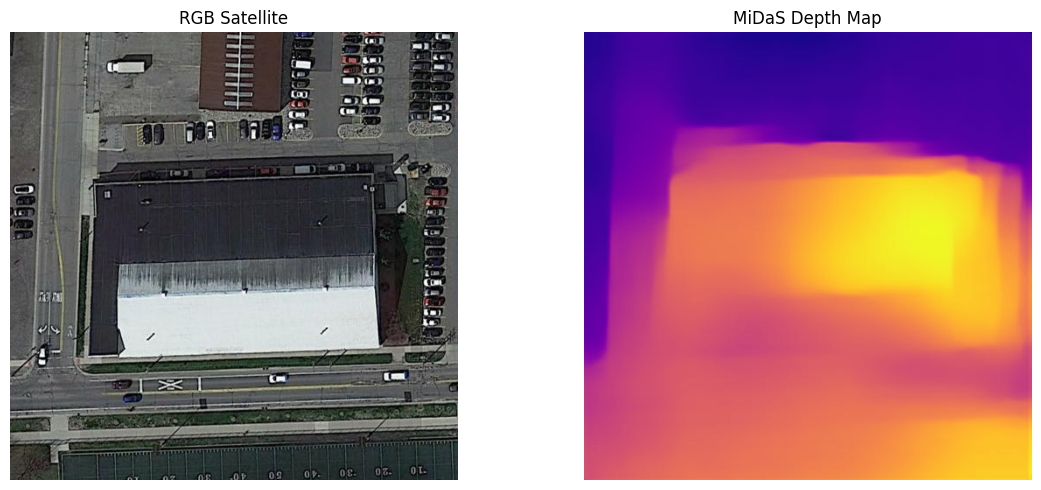


📌 Sonraki adım: model.py'yi 4 kanallı giriş için güncelle


In [37]:
# MiDaS Small kurulumu
!pip install -q timm

import torch
import cv2
import numpy as np
from PIL import Image
import os
from tqdm import tqdm

# MiDaS Small modelini yükle
midas = torch.hub.load("intel-isl/MiDaS", "MiDaS_small")
midas_transforms = torch.hub.load("intel-isl/MiDaS", "transforms")
transform = midas_transforms.small_transform

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
midas.to(device)
midas.eval()

print("✅ MiDaS Small yüklendi")

# Satellite görüntüleri için depth map oluştur
def generate_depth_maps(data_dir, output_dir):
    """Satellite görüntüleri için depth map oluştur"""
    os.makedirs(output_dir, exist_ok=True)

    # Train ve test satellite klasörlerini işle
    for split in ['train', 'test']:
        if split == 'train':
            sat_dir = os.path.join(data_dir, split, 'satellite')
        else:
            sat_dir = os.path.join(data_dir, split, 'query_satellite')

        if not os.path.exists(sat_dir):
            continue

        print(f"\n📊 {split} satellite görüntüleri işleniyor...")

        # Her sınıf klasörünü işle
        for class_name in tqdm(os.listdir(sat_dir)):
            class_path = os.path.join(sat_dir, class_name)
            if not os.path.isdir(class_path):
                continue

            output_class_dir = os.path.join(output_dir, split, 'satellite_depth', class_name)
            os.makedirs(output_class_dir, exist_ok=True)

            # Görüntüleri işle
            for img_name in os.listdir(class_path):
                if not img_name.lower().endswith(('.jpg', '.png', '.jpeg')):
                    continue

                img_path = os.path.join(class_path, img_name)
                output_path = os.path.join(output_class_dir, img_name)

                # Zaten işlendiyse atla
                if os.path.exists(output_path):
                    continue

                # Görüntüyü yükle
                img = cv2.imread(img_path)
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

                # MiDaS için hazırla
                input_batch = transform(img_rgb).to(device)

                # Depth tahmini
                with torch.no_grad():
                    prediction = midas(input_batch)
                    prediction = torch.nn.functional.interpolate(
                        prediction.unsqueeze(1),
                        size=img_rgb.shape[:2],
                        mode="bicubic",
                        align_corners=False,
                    ).squeeze()

                # Normalize et (0-255)
                depth_map = prediction.cpu().numpy()
                depth_normalized = cv2.normalize(depth_map, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

                # RGBD oluştur
                img_rgb_pil = Image.fromarray(img_rgb)
                depth_pil = Image.fromarray(depth_normalized)

                # 4 kanallı görüntü oluştur (RGB + D)
                rgbd = np.dstack((img_rgb, depth_normalized))

                # Kaydet (numpy array olarak)
                np.save(output_path.replace('.jpg', '.npy'), rgbd)

                # Görselleştirme için de kaydet
                Image.fromarray(rgbd[:,:,:3]).save(output_path)  # RGB
                depth_pil.save(output_path.replace('.jpg', '_depth.jpg'))  # Depth

    print(f"\n✅ Depth map'ler oluşturuldu: {output_dir}")

# Depth map'leri oluştur
data_dir = '/content/cvpr2017_cvusa'
output_dir = '/content/cvpr2017_cvusa_depth'

generate_depth_maps(data_dir, output_dir)

# Örnek görselleştirme
import matplotlib.pyplot as plt

# İlk örneği göster
sample_class = os.listdir(os.path.join(data_dir, 'train/satellite'))[0]
sample_img = os.listdir(os.path.join(data_dir, f'train/satellite/{sample_class}'))[0]

rgb_path = os.path.join(data_dir, f'train/satellite/{sample_class}/{sample_img}')
depth_path = os.path.join(output_dir, f'train/satellite_depth/{sample_class}/{sample_img.replace(".jpg", "_depth.jpg")}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(Image.open(rgb_path))
axes[0].set_title('RGB Satellite')
axes[0].axis('off')

axes[1].imshow(Image.open(depth_path), cmap='plasma')
axes[1].set_title('MiDaS Depth Map')
axes[1].axis('off')
plt.tight_layout()
plt.show()

print("\n📌 Sonraki adım: model.py'yi 4 kanallı giriş için güncelle")

## 4.5️⃣ MiDaS Depth Estimation Ekle (Opsiyonel)

In [38]:
import os

data_dir = '/content/cvpr2017_cvusa'

# Beklenen yapı
required_dirs = [
    f'{data_dir}/train/satellite',
    f'{data_dir}/train/drone',
    f'{data_dir}/test/query_satellite',
    f'{data_dir}/test/gallery_drone'
]

print("📂 Veri yapısı kontrolü:")
for d in required_dirs:
    exists = "✅" if os.path.exists(d) else "❌"
    print(f"{exists} {d}")

# İstatistikler
if os.path.exists(f'{data_dir}/train/satellite'):
    sat_count = len(os.listdir(f'{data_dir}/train/satellite'))
    drone_count = len(os.listdir(f'{data_dir}/train/drone'))
    print(f"\n📊 Train: {sat_count} satellite, {drone_count} drone sınıfı")

📂 Veri yapısı kontrolü:
✅ /content/cvpr2017_cvusa/train/satellite
✅ /content/cvpr2017_cvusa/train/drone
✅ /content/cvpr2017_cvusa/test/query_satellite
✅ /content/cvpr2017_cvusa/test/gallery_drone

📊 Train: 701 satellite, 701 drone sınıfı


## 5️⃣ Scriptleri Otomatik Düzenle (Satellite-Drone)

In [39]:
print("✅ Fork'unuzdan dosyalar yüklendi - düzenleme gerekmiyor!")
print("\n📄 Mevcut dosyalar:")

import os

# Dosya kontrolü
required_files = {
    'train_cvusa.py': 'Satellite-Drone eğitim scripti',
    'test_cvusa.py': 'Test scripti (query_satellite → gallery_drone)',
    'model_rgbd.py': 'RGBD model (4-kanallı)',
    'dataset_rgbd.py': 'RGBD dataset yükleyici',
    'README_RGBD.md': 'Kullanım kılavuzu'
}

for filename, description in required_files.items():
    if os.path.exists(filename):
        print(f"  ✅ {filename} - {description}")
    else:
        print(f"  ❌ {filename} - EKSIK!")

print("\n📌 Notlar:")
print("  • train_cvusa.py: Zaten satellite+drone için düzenlenmiş")
print("  • test_cvusa.py: query_satellite → gallery_drone yapılandırması")
print("  • model_rgbd.py: MiDaS depth için 4-kanallı model")
print("\n🎉 Direkt Hücre 10'a (Eğitim) geçebilirsiniz!")

✅ Fork'unuzdan dosyalar yüklendi - düzenleme gerekmiyor!

📄 Mevcut dosyalar:
  ✅ train_cvusa.py - Satellite-Drone eğitim scripti
  ✅ test_cvusa.py - Test scripti (query_satellite → gallery_drone)
  ✅ model_rgbd.py - RGBD model (4-kanallı)
  ✅ dataset_rgbd.py - RGBD dataset yükleyici
  ✅ README_RGBD.md - Kullanım kılavuzu

📌 Notlar:
  • train_cvusa.py: Zaten satellite+drone için düzenlenmiş
  • test_cvusa.py: query_satellite → gallery_drone yapılandırması
  • model_rgbd.py: MiDaS depth için 4-kanallı model

🎉 Direkt Hücre 10'a (Eğitim) geçebilirsiniz!


## 6️⃣ Eğitimi Başlat

In [41]:
# Eğitim parametreleri
EXPERIMENT_NAME = 'satellite_drone_colab'
BATCH_SIZE = 16      # T4 GPU için 16, A100 için 32-64
EPOCHS = 60
LEARNING_RATE = 0.01
POOL_TYPE = 'avg'    # avg, max, gem, avg+max
VIEWS = 2            # Satellite + Drone

!python train_cvusa.py \
    --name {EXPERIMENT_NAME} \
    --data_dir /content/cvpr2017_cvusa/train \
    --batchsize {BATCH_SIZE} \
    --lr {LEARNING_RATE} \
    --pool {POOL_TYPE} \
    --views {VIEWS} \
    --gpu_ids 0 \
    --h 384 \
    --w 384 \
    --stride 2 \
    --erasing_p 0.5 \
    --color_jitter

This is not an error. If you want to use low precision, i.e., fp16, please install the apex with cuda support (https://github.com/NVIDIA/apex) and update pytorch to 1.0
[ColorJitter(brightness=(0.9, 1.1), contrast=(0.9, 1.1), saturation=(0.9, 1.1), hue=None), Resize(size=(384, 384), interpolation=bicubic, max_size=None, antialias=True), Pad(padding=10, fill=0, padding_mode=edge), RandomCrop(size=(384, 384), padding=None), RandomHorizontalFlip(p=0.5), ToTensor(), Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), <random_erasing.RandomErasing object at 0x7f14cd514380>]
{'satellite': 701, 'drone': 37854}
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are depre

## 7️⃣ Eğitim Grafiği

In [44]:
from IPython.display import Image, display
import os

graph_path = f'model/{EXPERIMENT_NAME}/train.jpg'
if os.path.exists(graph_path):
    display(Image(graph_path))
else:
    print("📊 Grafik henüz oluşmadı")

📊 Grafik henüz oluşmadı


## 8️⃣ Test / Değerlendirme

In [45]:
!python test_cvusa.py \
    --name {EXPERIMENT_NAME} \
    --test_dir /content/cvpr2017_cvusa/test \
    --gpu_ids 0 \
    --which_epoch last

This is not an error. If you want to use low precision, i.e., fp16, please install the apex with cuda support (https://github.com/NVIDIA/apex) and update pytorch to 1.0
We use the scale: 1
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
-------test-----------
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a we

In [47]:
with open('test_cvusa.py', 'r') as f:
    lines = f.readlines()

# extract_feature fonksiyonunu bul ve yazdır
start = 0
end = 0
for i, line in enumerate(lines):
    if 'def extract_feature' in line:
        start = i
    if 'return features' in line and start != 0:
        end = i + 1
        break

if end == 0:
    end = start + 50 # Fallback

print("".join(lines[start:end]))

# Ayrıca gallery_name ve which_gallery atamalarını kontrol et
print("\n--- Global variable checks ---")
for i, line in enumerate(lines):
    if 'which_gallery =' in line or 'which_query =' in line:
        print(f"Line {i+1}: {line.strip()}")

def extract_feature(model,dataloaders, view_index = 1):
    features = torch.FloatTensor()
    count = 0
    for data in dataloaders:
        img, label = data
        n, c, h, w = img.size()
        count += n
        print(count)
        ff = torch.FloatTensor(n,512).zero_().cuda()

        for i in range(2):
            if(i==1):
                img = fliplr(img)
            input_img = Variable(img.cuda())
            for scale in ms:
                if scale != 1:
                    # bicubic is only  available in pytorch>= 1.1
                    input_img = nn.functional.interpolate(input_img, scale_factor=scale, mode='bilinear', align_corners=False)
                if opt.views ==2:
                    if view_index == 1:
                        outputs, _ = model(input_img, None) 
                    elif view_index ==2:
                        _, outputs = model(None, input_img) 
                elif opt.views ==3:
                    if view_index == 1:
                    

In [48]:
with open('test_cvusa.py', 'r') as f:
    lines = f.readlines()

print("🔍 Checking 'which_view' function:")
found = False
for i, line in enumerate(lines):
    if 'def which_view' in line:
        found = True
        print("".join(lines[i:i+15]))
        break
if not found:
    print("❌ Function not found")

🔍 Checking 'which_view' function:
def which_view(name):
    if 'satellite' in name:
        return 1
    elif 'street' in name:
        return 2
    elif 'drone' in name:
        return 3
    else:
        print('unknown view')
    return -1

def extract_feature(model,dataloaders, view_index = 1):
    features = torch.FloatTensor()
    count = 0
    for data in dataloaders:



In [49]:
file_path = 'test_cvusa.py'
with open(file_path, 'r') as f:
    content = f.read()

# Fix: Map drone to view 2 instead of 3 for 2-view configuration
old_logic = "elif 'drone' in name:\n        return 3"
new_logic = "elif 'drone' in name:\n        return 2"

if old_logic in content:
    content = content.replace(old_logic, new_logic)
    print("✅ Fixed 'drone' view index (3 -> 2) in test_cvusa.py")
else:
    print("ℹ️ Code already patched or pattern not found.")

with open(file_path, 'w') as f:
    f.write(content)

✅ Fixed 'drone' view index (3 -> 2) in test_cvusa.py


In [50]:
# Re-run the test command
!python test_cvusa.py \
    --name {EXPERIMENT_NAME} \
    --test_dir /content/cvpr2017_cvusa/test \
    --gpu_ids 0 \
    --which_epoch last

This is not an error. If you want to use low precision, i.e., fp16, please install the apex with cuda support (https://github.com/NVIDIA/apex) and update pytorch to 1.0
We use the scale: 1
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
-------test-----------
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a we

## 9️⃣ Modeli Kaydet (Google Drive)

In [51]:
# Drive'a kaydet
!mkdir -p /content/drive/MyDrive/University1652_models
!cp -r model/{EXPERIMENT_NAME} /content/drive/MyDrive/University1652_models/

print(f"✅ Model kaydedildi: /content/drive/MyDrive/University1652_models/{EXPERIMENT_NAME}")

# Veya zip'le indir
!cd model && zip -r {EXPERIMENT_NAME}.zip {EXPERIMENT_NAME}
from google.colab import files
files.download(f'model/{EXPERIMENT_NAME}.zip')

✅ Model kaydedildi: /content/drive/MyDrive/University1652_models/satellite_drone_colab
  adding: satellite_drone_colab/ (stored 0%)
  adding: satellite_drone_colab/result.txt (deflated 25%)
  adding: satellite_drone_colab/model.py (deflated 80%)
  adding: satellite_drone_colab/net_019.pth (deflated 7%)
  adding: satellite_drone_colab/net_039.pth (deflated 7%)
  adding: satellite_drone_colab/net_099.pth (deflated 7%)
  adding: satellite_drone_colab/net_079.pth (deflated 7%)
  adding: satellite_drone_colab/train.py (deflated 78%)
  adding: satellite_drone_colab/opts.yaml (deflated 36%)
  adding: satellite_drone_colab/net_059.pth (deflated 7%)
  adding: satellite_drone_colab/net_119.pth (deflated 7%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 🔟 Demo

usage: demo.py [-h] [--query_index QUERY_INDEX] [--test_dir TEST_DIR]
demo.py: error: unrecognized arguments: --name satellite_drone_colab --which_epoch last


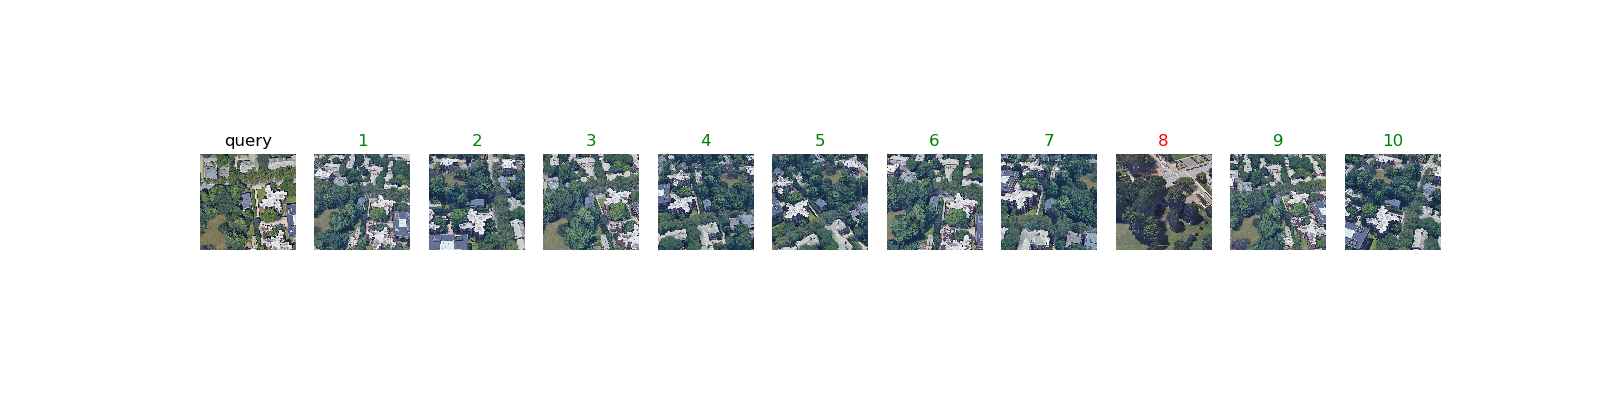

In [52]:
!python demo.py --name {EXPERIMENT_NAME} --which_epoch last

# Sonucu göster
if os.path.exists('show.png'):
    display(Image('show.png'))
else:
    print("Demo sonucu bulunamadı")

## ⚠️ ALTERNATİF: Manuel Dosya Yükleme

**Eğer Hücre 9'da sorun yaşıyorsanız bu yöntemi kullanın:**
1. Local bilgisayarınızdan düzenlenmiş `train_cvusa.py` ve `test_cvusa.py` dosyalarını yükleyin
2. Hücre 9'u **çalıştırmayın**, direkt Hücre 10'a geçin

In [ ]:
# Düzenlenmiş dosyaları local'den yükle
from google.colab import files
import shutil

print("📤 train_cvusa.py yükleyin...")
uploaded = files.upload()
if 'train_cvusa.py' in uploaded:
    shutil.copy('train_cvusa.py', '/content/University1652-Baseline/train_cvusa.py')
    print("✅ train_cvusa.py kopyalandı")

print("\n📤 test_cvusa.py yükleyin...")
uploaded = files.upload()
if 'test_cvusa.py' in uploaded:
    shutil.copy('test_cvusa.py', '/content/University1652-Baseline/test_cvusa.py')
    print("✅ test_cvusa.py kopyalandı")

print("\n✅ Dosyalar hazır! Hücre 10'a geçin.")